[노션 노트정리](https://app.notion.com/p/RNN-Kospi-3ea117a41d4d8078b1a9cee0ef64e875)

# **시퀀스 데이터**

시퀀스 데이터(Sequence Data)는 시간적 혹은 순서적 관계가 중요한 데이터를 말합니다. 

일반적인 데이터가 순서와 무관하게 독립적으로 다뤄지는 것과 달리, 시퀀스 데이터는 각 요소가 특정 순서에 따라 나열되어 있고 앞뒤 맥락이 의미를 가집니다. 

대표적인 예로는 자연어 문장(단어의 순서 중요), 시계열 데이터(주가, 날씨 변화), 음성 신호(시간에 따른 파형), 영상 프레임(연속된 이미지) 등이 있습니다. 

따라서 시퀀스 데이터는 단순한 값들의 모음이 아니라, 순서와 맥락이 포함된 정보 구조로 이해하는 것이 핵심입니다.

# **2. RNN**
RNN(Recurrent Neural Network, 순환 신경망)은 시계열 데이터나 연속적인 데이터를 다룰 때 사용되는 인공 신경망으로, 일반적인 신경망(CNN, MLP 등)이 입력을 한 번 처리하고 끝나는 것과 달리, 과거의 정보를 기억하며 다음 계산에 반영하는 특징이 있습니다. 

일반적인 신경망은 현재 입력만 보고 예측하지만, 시계열 데이터나 자연어처럼 이전 정보가 중요한 경우에는 적절하지 않기 때문에 RNN이 필요합니다. 

RNN은 기존 신경망과 달리 자신의 출력을 다시 입력으로 사용하여 과거 정보를 기억하는 구조를 가지며, 이를 통해 시계열 데이터의 패턴을 학습할 수 있습니다.  

그러나 일반적인 RNN은 장기 의존성(Long-Term Dependency) 문제로 인해 학습이 어려울 수 있으며, 이를 해결하기 위해 장단기 메모리(Long Short-Term Memory, LSTM)나 게이트 순환 유닛(Gated Recurrent Unit, GRU)과 같은 변형 모델이 개발되었습니다. 

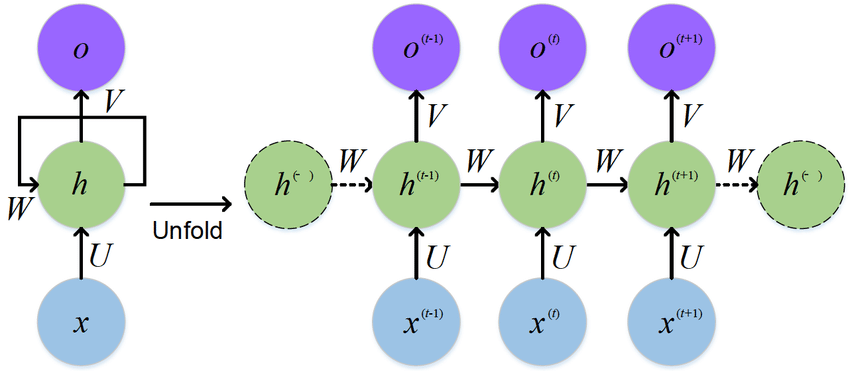
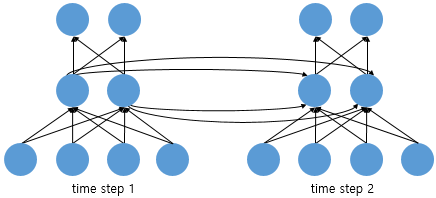

# **3. RNN을 이용한 KOSPI 예측**
- 최근 20 거래일의 정보를 하나의 입력 시퀀스로 만들어 그 다음 거래일의 종가(Close)를 예측

In [1]:
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [3]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
df = pd.read_csv("./data/kospi.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,04/01/2000,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,05/01/2000,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,06/01/2000,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,07/01/2000,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,10/01/2000,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0
...,...,...,...,...,...,...,...
4508,16/01/2018,2504.159912,2524.550049,2498.550049,2521.739990,2521.739990,341600.0
4509,17/01/2018,2517.189941,2521.969971,2506.489990,2515.429932,2515.429932,336700.0
4510,18/01/2018,2527.669922,2532.080078,2512.689941,2515.810059,2515.810059,333100.0
4511,19/01/2018,2519.669922,2524.330078,2513.090088,2520.260010,2520.260010,351800.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4513 non-null   str    
 1   Open       4452 non-null   float64
 2   High       4452 non-null   float64
 3   Low        4452 non-null   float64
 4   Close      4452 non-null   float64
 5   Adj Close  4452 non-null   float64
 6   Volume     4452 non-null   float64
dtypes: float64(6), str(1)
memory usage: 291.0 KB


In [6]:
df["Date"].dtype

<StringDtype(na_value=nan)>

In [7]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-04,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,2000-01-05,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,2000-01-06,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,2000-01-07,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,2000-01-10,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0
...,...,...,...,...,...,...,...
4508,2018-01-16,2504.159912,2524.550049,2498.550049,2521.739990,2521.739990,341600.0
4509,2018-01-17,2517.189941,2521.969971,2506.489990,2515.429932,2515.429932,336700.0
4510,2018-01-18,2527.669922,2532.080078,2512.689941,2515.810059,2515.810059,333100.0
4511,2018-01-19,2519.669922,2524.330078,2513.090088,2520.260010,2520.260010,351800.0


In [8]:
# 수치형 데이터 전처리를 위한 설정
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

# 예외를 위한 수치형 변환
for col in numeric_cols:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
# 필요한 열만 뽑아주기
required_cols = ["Date", "Open", "High", "Low", "Close"]

# 결측치가 있는 행은 없애주기 
df_copy = df.dropna(subset=required_cols).copy()
df_copy.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-04,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,2000-01-05,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,2000-01-06,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,2000-01-07,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,2000-01-10,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0


In [10]:
df_copy = df_copy.sort_values("Date").reset_index(drop=True)
print("데이터 기간:", df_copy["Date"].min(), " ~ ", df_copy["Date"].max())
print("전체 행 수:", len(df_copy))

데이터 기간: 2000-01-04 00:00:00  ~  2018-01-22 00:00:00
전체 행 수: 4452


In [11]:
df_copy.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-04,1028.329956,1066.180054,1016.590027,1059.040039,1059.040039,19589800.0
1,2000-01-05,1006.869995,1026.520020,984.049988,986.309998,986.309998,25769600.0
2,2000-01-06,1013.950012,1014.900024,953.500000,960.789978,960.789978,20352300.0
3,2000-01-07,949.169983,970.159973,930.840027,948.650024,948.650024,21566400.0
4,2000-01-10,979.669983,994.940002,974.820007,987.239990,987.239990,24017500.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4513 non-null   datetime64[us]
 1   Open       4452 non-null   float64       
 2   High       4452 non-null   float64       
 3   Low        4452 non-null   float64       
 4   Close      4452 non-null   float64       
 5   Adj Close  4452 non-null   float64       
 6   Volume     4452 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 246.9 KB


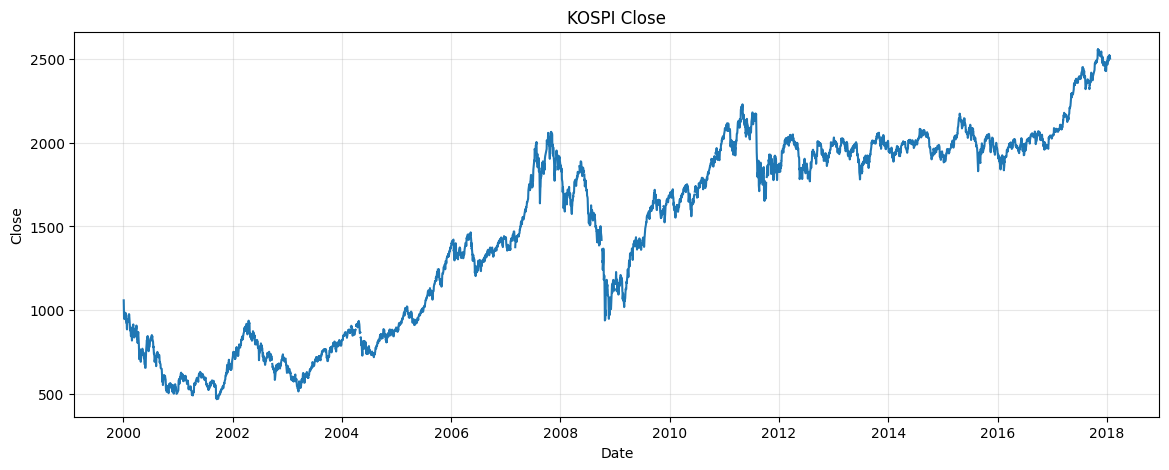

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"])
plt.title("KOSPI Close")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(alpha=0.3)
plt.show()

In [14]:
data = df.copy()

data["Return_1d"] = data["Close"].pct_change()
data["Range_pct"] = (data["High"] - data["Low"]) / data["Close"]
data["OC_pct"] = (data["Close"] - data["Open"]) / data["Open"]

data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()

data["MA5_ratio"] = data["Close"] / data["MA5"]
data["MA20_ratio"] = data["Close"] / data["MA20"]

data["Volatility_10"] = data["Return_1d"].rolling(10).std()

# 다음 거래일 종가와 날짜를 정답으로 사용합니다.
data["Target_Close"] = data["Close"].shift(-1)
data["Target_Date"] = data["Date"].shift(-1)

FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Return_1d",
    "Range_pct",
    "OC_pct",
    "MA5_ratio",
    "MA20_ratio",
    "Volatility_10",
]

# rolling으로 생긴 앞부분 NaN과 마지막 target NaN을 제거합니다.
data = data.dropna(subset=FEATURES + ["Target_Close", "Target_Date"]).reset_index(drop=True)

print("사용할 Feature 개수:", len(FEATURES))
print("정제 후 데이터 수:", len(data))
data[["Date"] + FEATURES + ["Target_Date", "Target_Close"]].head()

사용할 Feature 개수: 10
정제 후 데이터 수: 3634


,Date,Open,High,Low,Close,Return_1d,Range_pct,OC_pct,MA5_ratio,MA20_ratio,Volatility_10,Target_Date,Target_Close
0,2000-01-31,924.830017,948.840027,922.919983,943.880005,0.002347,0.027461,0.020598,1.032344,0.990929,0.025395,2000-02-01,928.750000
1,2000-02-01,955.440002,959.309998,923.520020,928.750000,-0.016030,0.038536,-0.027935,1.007524,0.981760,0.025668,2000-02-02,943.590027
2,2000-02-02,929.690002,950.130005,923.400024,943.590027,0.015978,0.028328,0.014951,1.010891,0.999704,0.022495,2000-02-03,950.219971
3,2000-02-03,950.260010,959.000000,934.109985,950.219971,0.007026,0.026194,-0.000042,1.009131,1.007292,0.022477,2000-02-07,973.130005
4,2000-02-07,953.229980,982.030029,951.309998,973.130005,0.024110,0.031568,0.020876,1.026602,1.030241,0.022042,2000-02-08,961.219971


In [67]:
len(test_mask)

3615

### Train/Validation/Test 분리
- 시계열에서 랜덤 분할을 하면 미래 시점의 데ㅣ터가 Train에 들어가고 과거 시점이 Test에 들어가는 비 현실적인 평가가 될 수 있기 때문에 시간순으로 나누어야함

In [15]:
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

print("Train rows :", train_end)
print("Valid rows :", val_end - train_end)
print("Test rows  :", n - val_end)

print()
print("Train target 기간:",
      data.loc[0, "Target_Date"], "~",
      data.loc[train_end - 1, "Target_Date"])

print("Valid target 기간:",
      data.loc[train_end, "Target_Date"], "~",
      data.loc[val_end - 1, "Target_Date"])

print("Test target 기간 :",
      data.loc[val_end, "Target_Date"], "~",
      data.loc[n - 1, "Target_Date"])

Train rows : 2543
Valid rows : 545
Test rows  : 546

Train target 기간: 2000-02-01 00:00:00 ~ 2013-05-09 00:00:00
Valid target 기간: 2013-05-10 00:00:00 ~ 2015-07-28 00:00:00
Test target 기간 : 2015-07-29 00:00:00 ~ 2018-01-22 00:00:00


### Scaling
Open/High/Low/Close는 수백 또는 수천 단위이고, OC_pct 같은건 0에 가까운 소수이므로 그대로 학습하면 feature별 숫자 크기가 커져 이를 조정해줍니다.


In [16]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

scaler_x.fit(data.loc[:train_end - 1, FEATURES])
scaler_y.fit(data.loc[:train_end - 1, ["Target_Close"]])

X_all = scaler_x.transform(data[FEATURES]).astype(np.float32)
y_all = scaler_y.transform(data[["Target_Close"]]).astype(np.float32)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

X_all shape: (3634, 10)
y_all shape: (3634, 1)


In [17]:
SEQUENCE_LENGTH = 20

def make_sequence(X, y, sequence_length):
  X_seq = []
  y_seq = []
  target_indices = []

  for i in range(sequence_length-1, len(X)):
    start = i -  sequence_length + 1
    X_seq.append(X[start:i+1])
    y_seq.append(y[i])
    target_indices.append(i)

  return (
    np.asarray(X_seq, dtype=np.float32), 
    np.asarray(y_seq, dtype=np.float32),
    np.asarray(target_indices, dtype=np.int64),
  )

In [18]:
X_seq, y_seq, target_indices = make_sequence(X_all, y_all, SEQUENCE_LENGTH)
print("전체 sequence shape:", X_seq.shape)
print("전체 target shape:", y_seq.shape)
print("target indicies shape:", target_indices.shape)

전체 sequence shape: (3615, 20, 10)
전체 target shape: (3615, 1)
target indicies shape: (3615,)


In [19]:
target_indices

array([  19,   20,   21, ..., 3631, 3632, 3633], shape=(3615,))

# Dataset과 DataLoader

In [ ]:
# train만 1인 마스크
train_mask = target_indices < train_end
val_mask = (target_indices >= train_end) & (target_indices < val_end)
test_mask = target_indices >= val_end
train_mask.mean(), val_mask.mean(), test_mask.mean()

(np.float64(0.6982019363762102),
 np.float64(0.1507607192254495),
 np.float64(0.15103734439834024))

In [25]:
# train split
X_train, y_train = X_seq[train_mask], y_seq[train_mask]
# val   split
X_val, y_val = X_seq[val_mask], y_seq[val_mask]
# test  split
X_test, y_test = X_seq[test_mask], y_seq[test_mask]

idx_train = target_indices[train_mask]
idx_val = target_indices[val_mask]
idx_test = target_indices[test_mask]

print("Train: ", X_train.shape, y_train.shape)
print("Valid: ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train:  (2524, 20, 10) (2524, 1)
Valid:  (545, 20, 10) (545, 1)
Test:  (546, 20, 10) (546, 1)


In [28]:
class SequenceDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [42]:
BATCH_SIZE = 64

train_loader = DataLoader(
  dataset=SequenceDataset(X_train, y_train),
  batch_size=BATCH_SIZE,
  shuffle=True
)

val_loader = DataLoader(
  dataset=SequenceDataset(X_val, y_val),
  batch_size=BATCH_SIZE,
  shuffle=False
)

test_loader = DataLoader(
  dataset=SequenceDataset(X_test, y_test),
  batch_size=BATCH_SIZE,
  shuffle=False
)

In [43]:
xb, yb = next(iter(train_loader))
xb.shape, yb.shape

(torch.Size([64, 20, 10]), torch.Size([64, 1]))

In [ ]:
class RNNRegressor(nn.Module):
  def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.10):
    super().__init__()
    self.rnn = nn.RNN(
      input_size=input_size,
      hidden_size=hidden_size,
      num_layers=num_layers,
      nonlinearity="tanh",
      batch_first=True,
      dropout=dropout if num_layers > 1 else 0.0
    )
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    # out: 모든 time step의 마지막 RNN Layer을 출력하게 됨.
    # h_n: rnn layer의 마지막 hidden state
    out, h_n = self.rnn(x)

    # out.shape: [batch, sequence_length, hidden_size]
    last_hidden = out[:, -1, :]
    pred = self.fc(last_hidden)
    
    return pred

In [45]:
model = RNNRegressor(
  input_size=len(FEATURES),
  hidden_size=64,
  num_layers=2,
  dropout=0.1
).to(DEVICE)

model

RNNRegressor(
  (rnn): RNN(10, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [46]:
model.eval()

with torch.no_grad():
  sample_x = xb[:4].to(DEVICE)
  out, h_n = model.rnn(sample_x)

print("입력 sample_x:", sample_x.shape)
print("RNN out:", out.shape)
print("RNN h_n shape:", h_n.shape)
print("마지막 시점:", out[:, -1, :].shape)

입력 sample_x: torch.Size([4, 20, 10])
RNN out: torch.Size([4, 20, 64])
RNN h_n shape: torch.Size([2, 4, 64])
마지막 시점: torch.Size([4, 64])


In [ ]:
# HuberLoss: 회귀 문제에서 MSE와 MAE의 장점을 섞음. 오차가 작으면 제곱처럼 계산하고, 오차가 크면 선형적으로 계산
criterion = nn.HuberLoss(delta=1.0) # delta: 관계선
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

MAX_EPOCHS = 200
PATIENCE = 15
# 기울기 폭발 방지
CLIP_NORM = 1.0

In [48]:
def evaluate_loss(model, loader, criterion, device):
  model.eval()
  total_loss = 0.0
  total_count = 0

  with torch.no_grad():
    for xb, yb in loader:
      xb = xb.to(device)
      yb = yb.to(device)
      pred = model(xb)
      loss = criterion(pred, yb)
      
      batch_size = xb.size(0)
      total_loss += loss.item() * batch_size
      total_count += batch_size

  return total_loss / total_count

In [50]:
best_val_loss = float("inf")
best_state = None
# patience counter 계열
wait = 0

train_history = []
val_history = []

for epoch in range(1, MAX_EPOCHS+1):
  model.train()

  train_loss_sum = 0.0
  train_count = 0

  for xb, yb in train_loader:
    xb = xb.to(DEVICE)
    yb = yb.to(DEVICE)
    optimizer.zero_grad(set_to_none=True)
    
    pred = model(xb)
    loss = criterion(pred, yb)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
    optimizer.step()

    batch_size = xb.size(0)
    train_count += batch_size
    train_loss_sum += loss.item() * batch_size

  train_loss = train_loss_sum / train_count
  val_loss = evaluate_loss(model, val_loader, criterion, DEVICE)
  train_history.append(train_loss)
  val_history.append(val_loss)
  scheduler.step(val_loss)

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_state = copy.deepcopy(model.state_dict())
    wait=0
  else:
    wait += 1

  if epoch == 1 or epoch % 10 == 0:
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d} | Train {train_loss:.6f} | Valid {val_loss:.6f} | LR {lr:.2e}")
  if wait >= PATIENCE:
    print(f"Early Stopping: epoch {epoch}")
    break

Epoch 001 | Train 0.004686 | Valid 0.000914 | LR 1.00e-03
Epoch 010 | Train 0.001680 | Valid 0.000421 | LR 1.00e-03
Epoch 020 | Train 0.001351 | Valid 0.000475 | LR 1.00e-03
Epoch 030 | Train 0.001109 | Valid 0.000424 | LR 5.00e-04
Epoch 040 | Train 0.001061 | Valid 0.000433 | LR 5.00e-04
Epoch 050 | Train 0.001027 | Valid 0.000482 | LR 2.50e-04
Epoch 060 | Train 0.000918 | Valid 0.000389 | LR 6.25e-05
Early Stopping: epoch 62


In [51]:
if best_state is not None:
  model.load_state_dict(best_state)

print("Best validation loss:", best_val_loss)

Best validation loss: 0.0003663760211549426


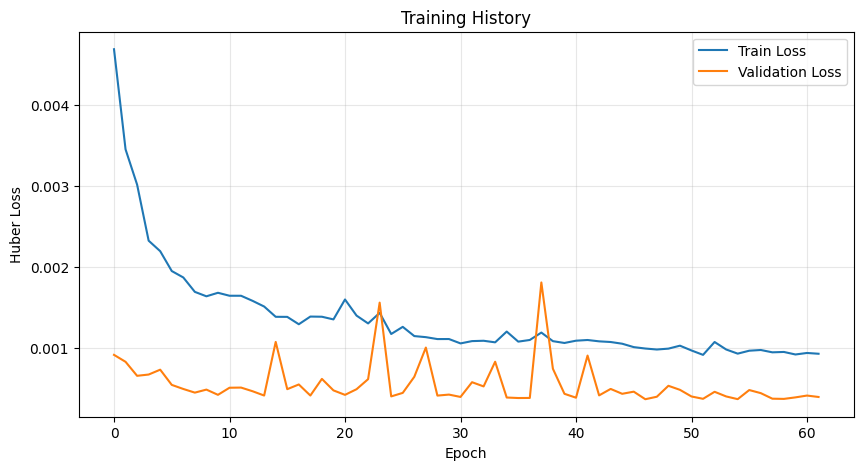

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
def predict(model, loader, device):
  model.eval()

  preds = []
  trues = []

  with torch.no_grad():
    for xb, yb in loader:
      xb = xb.to(device)
      pred = model(xb)
      preds.append(pred.cpu().numpy())
      trues.append(yb.numpy())

  return np.vstack(preds), np.vstack(trues)

In [56]:
pred_scaled, true_scaled = predict(model, test_loader, DEVICE)

In [ ]:
# ravel(): Numpy 배열을 1차원으로 펴는 함수
pred_close = scaler_y.inverse_transform(pred_scaled).ravel()
true_close = scaler_y.inverse_transform(true_scaled).ravel()
print("예측 개수:", len(pred_close))
print("예측 값 앞 5개:", np.round(pred_close[:5], 2))
print("실제 값 앞 5개:", np.round(true_close[:5], 2))

예측 개수: 546
예측 값 앞 5개: [2035.61 2037.36 2022.8  2026.61 2008.9 ]
실제 값 앞 5개: [2037.62 2019.03 2030.16 2008.49 2027.99]


In [59]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

print("MSE:", mean_squared_error(true_close, pred_close))
print("RMSE:", root_mean_squared_error(true_close, pred_close))
print("R2:", r2_score(true_close, pred_close))

MSE: 3892.959228515625
RMSE: 62.39358139038086
R2: 0.902327835559845


In [76]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }

regression_metrics(true_close, pred_close)

{'MSE': 3892.959228515625,
 'RMSE': 62.393583231896734,
 'MAE': 39.170738220214844,
 'MAPE (%)': 1.6760317087173462}

In [77]:
rnn_metrics = regression_metrics(true_close, pred_close)
for name, value in rnn_metrics.items():
    print(f"{name}: {value:.4f}")

MSE: 3892.9592
RMSE: 62.3936
MAE: 39.1707
MAPE (%): 1.6760


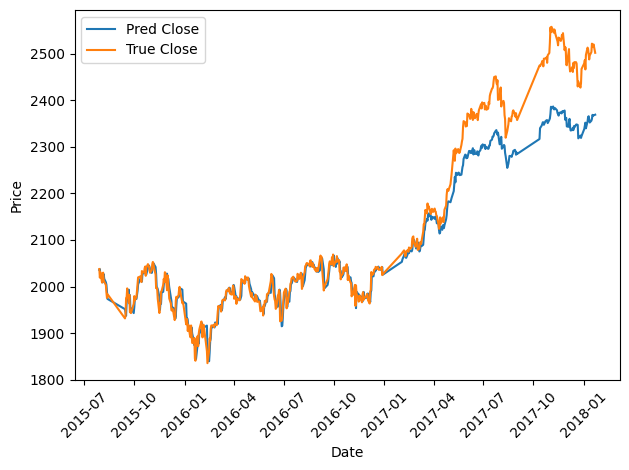

In [73]:
test_dates = pd.to_datetime(data.loc[idx_test, "Target_Date"])
plt.plot(test_dates, pred_close, label="Pred Close")
plt.plot(test_dates, true_close, label="True Close")
plt.ylabel("Price")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [79]:
current_close = data.loc[idx_test, "Close"].to_numpy()
# Naive 예측: 내일 종가 = 오늘 종가
naive_pred = current_close.copy()
naive_metrics = regression_metrics(true_close, naive_pred)
comparison = pd.DataFrame([rnn_metrics, naive_metrics], index=["RNN", "Naive Baseline"])
comparison

,MSE,RMSE,MAE,MAPE (%)
RNN,3892.959229,62.393583,39.170738,1.676032
Naive Baseline,215.416230,14.677065,10.755585,0.512224


In [80]:
actual_direction = np.sign(true_close - current_close)
pred_direction = np.sign(pred_close - current_close)
naive_direction = np.sign(naive_pred - current_close)

prev_close = data.loc[idx_test - 1, "Close"].to_numpy()
prev_direction = np.sign(current_close - prev_close)

direction_accuracy = np.mean(actual_direction == pred_direction) * 100
naive_direction_accuracy = np.mean(actual_direction == naive_direction) * 100
prev_direction_accuracy = np.mean(actual_direction == prev_direction) * 100

print(f"RNN Direction Accuracy          : {direction_accuracy:.2f}%")
print(f"Naive(오늘=내일) Direction Acc. : {naive_direction_accuracy:.2f}%")
print(f"Previous Direction Baseline     : {prev_direction_accuracy:.2f}%")

RNN Direction Accuracy          : 48.17%
Naive(오늘=내일) Direction Acc. : 0.00%
Previous Direction Baseline     : 48.90%


In [82]:
test_datas = pd.to_datetime(data.loc[idx_test, "Target_Date"].to_numpy())
test_datas

DatetimeIndex(['2015-07-29', '2015-07-30', '2015-07-31', '2015-08-03',
               '2015-08-04', '2015-08-05', '2015-08-06', '2015-08-07',
               '2015-08-10', '2015-08-11',
               ...
               '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12',
               '2018-01-15', '2018-01-16', '2018-01-17', '2018-01-18',
               '2018-01-19', '2018-01-22'],
              dtype='datetime64[us]', length=546, freq=None)

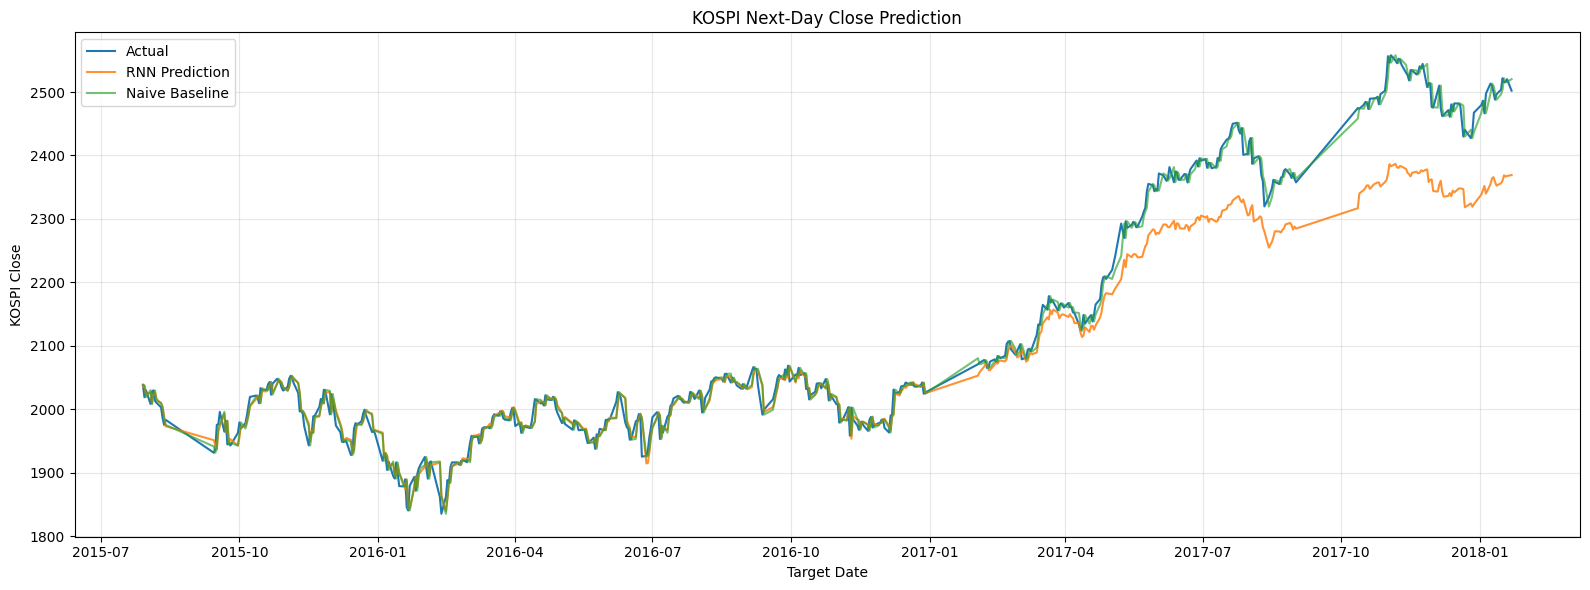

In [83]:
plt.figure(figsize=(16, 6))
plt.plot(test_dates, true_close, label="Actual")
plt.plot(test_dates, pred_close, label="RNN Prediction", alpha=0.85)
plt.plot(test_dates, naive_pred, label="Naive Baseline", alpha=0.65)

plt.title("KOSPI Next-Day Close Prediction")
plt.xlabel("Target Date")
plt.ylabel("KOSPI Close")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

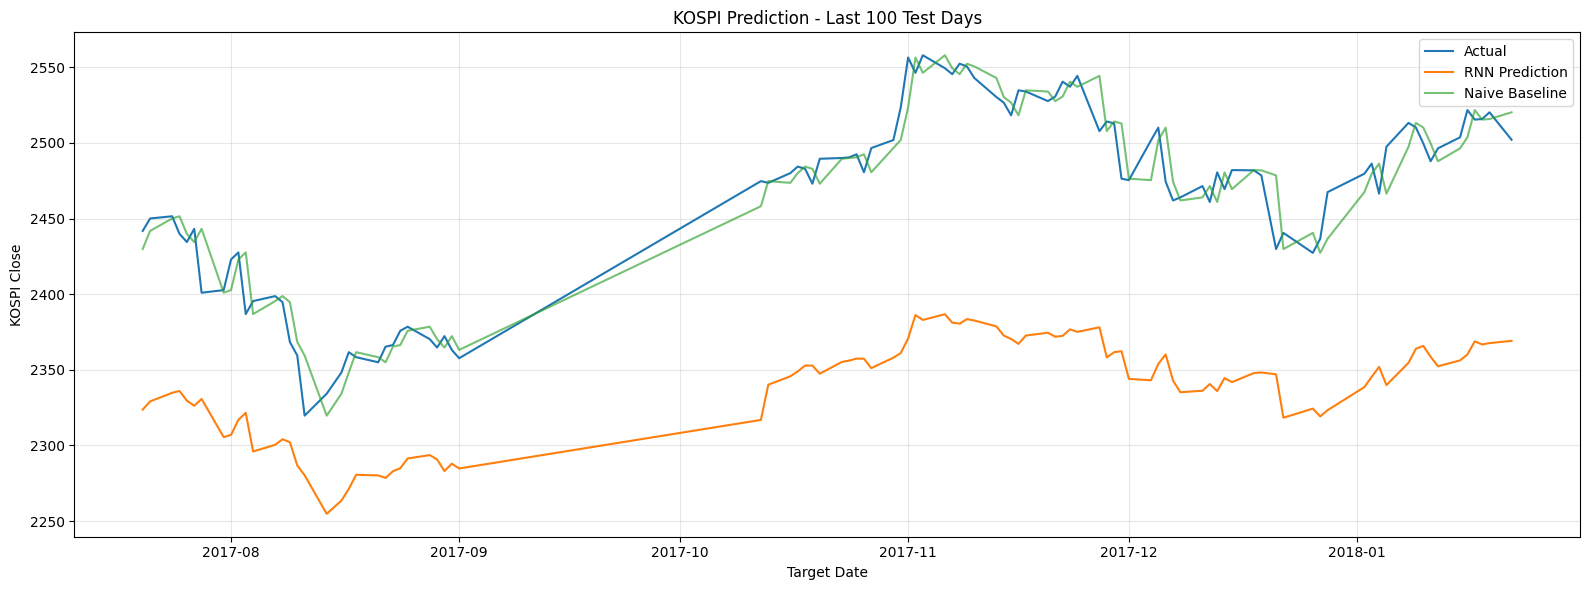

In [84]:
N_VIEW = min(100, len(test_dates))

plt.figure(figsize=(16, 6))

plt.plot(
    test_dates[-N_VIEW:],
    true_close[-N_VIEW:],
    label="Actual"
)

plt.plot(
    test_dates[-N_VIEW:],
    pred_close[-N_VIEW:],
    label="RNN Prediction"
)

plt.plot(
    test_dates[-N_VIEW:],
    naive_pred[-N_VIEW:],
    label="Naive Baseline",
    alpha=0.65
)

plt.title(f"KOSPI Prediction - Last {N_VIEW} Test Days")
plt.xlabel("Target Date")
plt.ylabel("KOSPI Close")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
result_df = pd.DataFrame({
    "Target_Date": test_dates,
    "Current_Close": current_close,
    "Actual_Next_Close": true_close,
    "RNN_Prediction": pred_close,
    "Naive_Prediction": naive_pred,
})

result_df["RNN_Error"] = (
    result_df["Actual_Next_Close"]
    - result_df["RNN_Prediction"]
)

result_df.tail(20)

,Target_Date,Current_Close,Actual_Next_Close,RNN_Prediction,Naive_Prediction,RNN_Error
3614,2017-12-21,2478.530029,2429.830078,2347.064697,2478.530029,82.765381
3615,2017-12-22,2429.830078,2440.540039,2318.335449,2429.830078,122.204590
3616,2017-12-26,2440.540039,2427.339844,2324.374512,2440.540039,102.965332
3617,2017-12-27,2427.340088,2436.669922,2319.215820,2427.340088,117.454102
3618,2017-12-28,2436.669922,2467.489990,2323.318359,2436.669922,144.171631
3619,2018-01-02,2467.489990,2479.649902,2338.589600,2467.489990,141.060303
3620,2018-01-03,2479.649902,2486.350098,2345.420654,2479.649902,140.929443
3621,2018-01-04,2486.350098,2466.459961,2351.987793,2486.350098,114.472168
3622,2018-01-05,2466.459961,2497.520020,2339.933105,2466.459961,157.586914
3623,2018-01-08,2497.520020,2513.279785,2354.663086,2497.520020,158.616699
